In [1]:
# Célula 1 — Imports e carregamento
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\thayn\fiap-tech-challenge-churn\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_clean = df.dropna().copy()

print("Shape:", df.shape)
print("Churn:\n", df['Churn'].value_counts())
df.head()

Shape: (7043, 21)
Churn:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


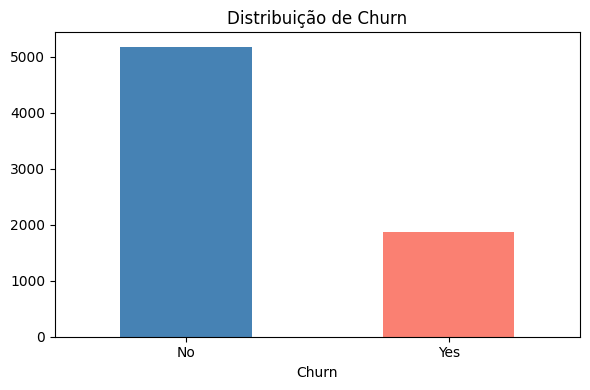

Proporção: {'No': 0.735, 'Yes': 0.265}


In [2]:
# Célula 2 — Distribuição de Churn
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Distribuição de Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("Proporção:", df['Churn'].value_counts(normalize=True).round(3).to_dict())

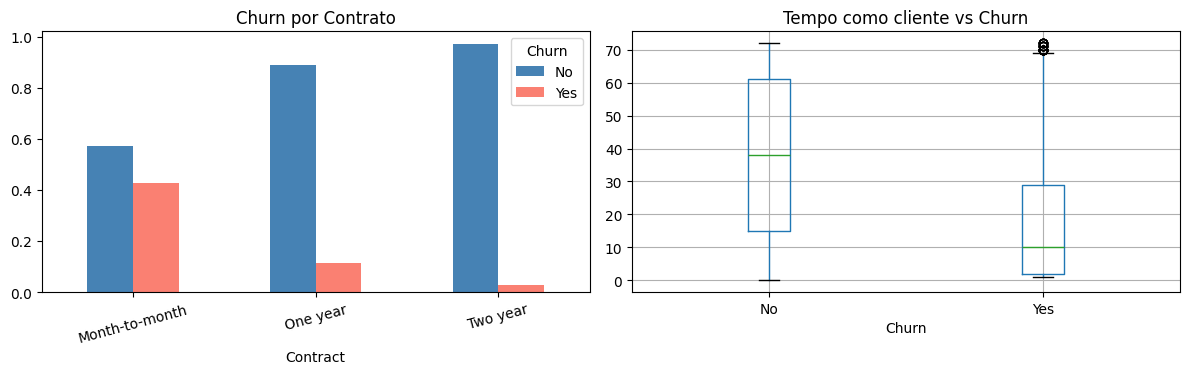

In [3]:
# Célula 3 — Fatores de risco
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Churn por Contrato')
axes[0].tick_params(axis='x', rotation=15)
df.boxplot(column='tenure', by='Churn', ax=axes[1])
axes[1].set_title('Tempo como cliente vs Churn')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [5]:
print("=== INFORMAÇÕES GERAIS ===")
print(df.info())
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())
print("\n=== DUPLICATAS ===")
print("Linhas duplicadas:", df.duplicated().sum())

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

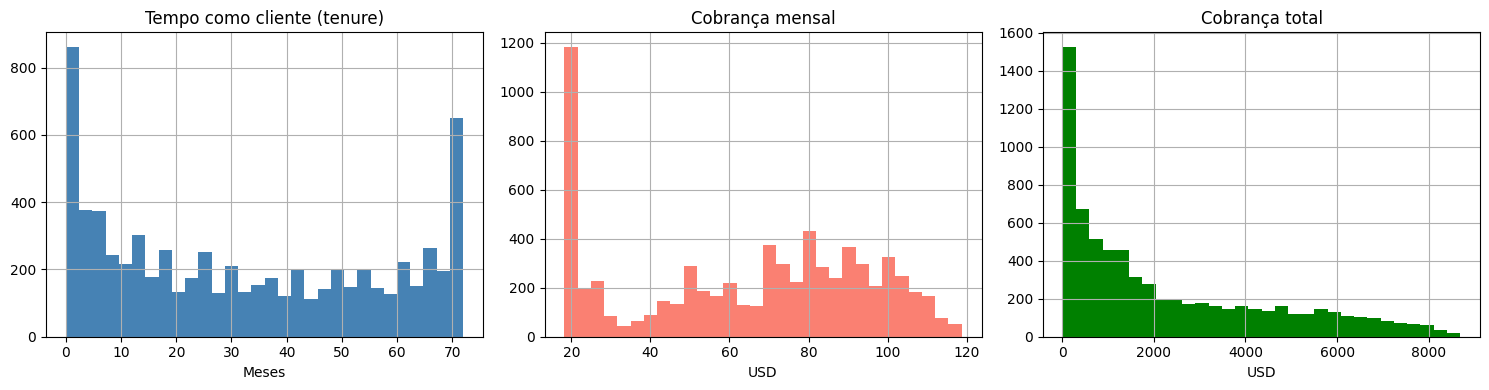

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['tenure'].hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Tempo como cliente (tenure)')
axes[0].set_xlabel('Meses')
df['MonthlyCharges'].hist(ax=axes[1], bins=30, color='salmon')
axes[1].set_title('Cobrança mensal')
axes[1].set_xlabel('USD')
df['TotalCharges'].hist(ax=axes[2], bins=30, color='green')
axes[2].set_title('Cobrança total')
axes[2].set_xlabel('USD')
plt.tight_layout()
plt.show()

In [7]:
print("=== RESUMO DO EDA ===")
print(f"Total de clientes: {len(df_clean)}")
print(f"Taxa de churn: {(df_clean['Churn']=='Yes').mean():.1%}")
print(f"\nPrincipais fatores de risco:")
print("- Contrato mês a mês (~42% de churn)")
print("- Fiber optic sem suporte técnico")
print("- Clientes com menos de 12 meses")
df_clean.to_csv(r'C:\Users\thayn\fiap-tech-challenge-churn\data\processed\telco_clean.csv', index=False)
print(f"\nDataset limpo salvo: {len(df_clean)} registros")

=== RESUMO DO EDA ===
Total de clientes: 7032
Taxa de churn: 26.6%

Principais fatores de risco:
- Contrato mês a mês (~42% de churn)
- Fiber optic sem suporte técnico
- Clientes com menos de 12 meses

Dataset limpo salvo: 7032 registros
